# Importing Necessary Libraries

In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Data Preprocessing and Data Quality

In [24]:
### DATA PREPROCESSING

df = pd.read_csv("semi_conductor_se.csv")

print("Raw dataset shape (rows, columns):", df.shape)
print("Raw dataset total rows:", len(df))

# 2. Drop unwanted index column (if present)
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])


# 3. Parse date column
df["date"] = pd.to_datetime(df["date"])


# 4. Filter time range (2015–2025)
START_DATE = "2015-01-01"
END_DATE   = "2025-08-04"

df = df[(df["date"] >= START_DATE) & (df["date"] <= END_DATE)]

print("After date filter:", df.shape)
print("Rows:", len(df))

# 5. Select tickers

selected_tickers = [
    "NVDA", "AMD", "INTC", "AVGO", "TSM",
    "NXPI", "ASML", "AMAT", "LRCX", "QCOM",
    "MU", "TXN", "ADI", "ON", "MRVL",
    "KLAC", "MCHP", "STM", "IFX.DE"
]

df = df[df["stock_name"].isin(selected_tickers)]

print("After ticker filter:", df.shape)
print("Rows:", len(df))



# 6. Sort data (important for time series)
df = df.sort_values(["stock_name", "date"]).reset_index(drop=True)


# 7. Basic sanity checks
print("\nFinal dataset checks:")
print("Number of unique tickers:", df["stock_name"].nunique())
print("Date range:",
      df["date"].min().date(), "to", df["date"].max().date())
print("Final total rows:", len(df))


# 8. Save filtered dataset
df.to_csv("semiconductor_stocks_data_2015_2025.csv", index=False)

print(f"\nFiltered dataset saved as: semiconductor_stocks_data_2015_2025.csv")


Raw dataset shape (rows, columns): (422729, 9)
Raw dataset total rows: 422729
After date filter: (343398, 8)
Rows: 343398
After ticker filter: (50589, 8)
Rows: 50589

Final dataset checks:
Number of unique tickers: 19
Date range: 2015-01-02 to 2025-08-01
Final total rows: 50589

Filtered dataset saved as: semiconductor_stocks_data_2015_2025.csv


In [25]:
df=pd.read_csv("semiconductor_stocks_data_2015_2025.csv")
df.head()

,company_name,stock_name,date,open,high,low,close,volume
0,Analog Devices,ADI,2015-01-02,44.799830,45.258449,44.228568,44.687187,1323200
1,Analog Devices,ADI,2015-01-05,44.574549,44.614779,43.850413,43.874550,1445200
2,Analog Devices,ADI,2015-01-06,44.035461,44.091783,42.812477,42.844662,1707500
3,Analog Devices,ADI,2015-01-07,43.037761,43.552701,42.667645,43.295231,1723000
4,Analog Devices,ADI,2015-01-08,43.761902,44.397532,43.512479,44.059601,1874900


In [26]:
df.tail()

,company_name,stock_name,date,open,high,low,close,volume
50584,Texas Instruments,TXN,2025-07-28,186.531773,189.172674,186.402701,187.891937,8586800
50585,Texas Instruments,TXN,2025-07-29,188.348639,191.505812,187.544439,190.006653,7144700
50586,Texas Instruments,TXN,2025-07-30,190.771120,191.198043,186.948757,188.160004,6985100
50587,Texas Instruments,TXN,2025-07-31,186.139999,186.910004,179.809998,181.059998,10144000
50588,Texas Instruments,TXN,2025-08-01,179.630005,181.589996,177.919998,180.860001,6623900


Data Sanity Check

In [27]:
df.shape 

(50589, 8)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50589 entries, 0 to 50588
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   company_name  50589 non-null  object 
 1   stock_name    50589 non-null  object 
 2   date          50589 non-null  object 
 3   open          50589 non-null  float64
 4   high          50589 non-null  float64
 5   low           50589 non-null  float64
 6   close         50589 non-null  float64
 7   volume        50589 non-null  int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 3.1+ MB


In [29]:
#Looking for missing values
df.isnull().sum()

company_name    0
stock_name      0
date            0
open            0
high            0
low             0
close           0
volume          0
dtype: int64

In [30]:
#Looking for duplicates
df.duplicated().sum()


np.int64(0)

In [31]:
#Looking for garbage values
for i in df.select_dtypes (include="object").columns:
 print(df[i].value_counts())
 print("***"*10)
 

company_name
Infineon                2691
Applied Materials       2661
Analog Devices          2661
AMD                     2661
ASML                    2661
Broadcom                2661
Intel                   2661
KLA                     2661
Lam Research            2661
Microchip Technology    2661
Marvell Technology      2661
Micron Technology       2661
NVIDIA                  2661
NXP Semiconductors      2661
ON Semiconductor        2661
QUALCOMM                2661
STMicroelectronics      2661
TSMC                    2661
Texas Instruments       2661
Name: count, dtype: int64
******************************
stock_name
IFX.DE    2691
AMAT      2661
ADI       2661
AMD       2661
ASML      2661
AVGO      2661
INTC      2661
KLAC      2661
LRCX      2661
MCHP      2661
MRVL      2661
MU        2661
NVDA      2661
NXPI      2661
ON        2661
QCOM      2661
STM       2661
TSM       2661
TXN       2661
Name: count, dtype: int64
******************************
date
2025-08-01    19
2025

## Exploratory Data Analysis (EDA) and Visualization

In [32]:
#descriptive statistics 
df.describe()

,open,high,low,close,volume
count,50589.000000,50589.000000,50589.000000,50589.000000,5.058900e+04
mean,90.721203,91.941479,89.450244,90.724579,3.665891e+07
std,129.335066,130.975824,127.583072,129.331154,1.160146e+08
min,0.463628,0.467947,0.454509,0.459308,0.000000e+00
25%,23.656285,23.981890,23.309616,23.647720,3.360200e+06
50%,49.976784,50.589230,49.314851,49.939941,7.211300e+06
75%,102.320894,103.709999,101.034279,102.352776,1.873920e+07
max,1096.841562,1096.950245,1063.095736,1085.942017,3.692928e+09


In [33]:
df.describe(include='object')

,company_name,stock_name,date
count,50589,50589,50589
unique,19,19,2733
top,Infineon,IFX.DE,2025-08-01
freq,2691,2691,19


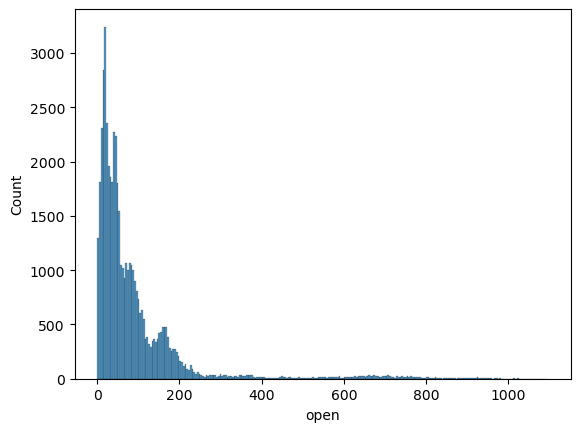

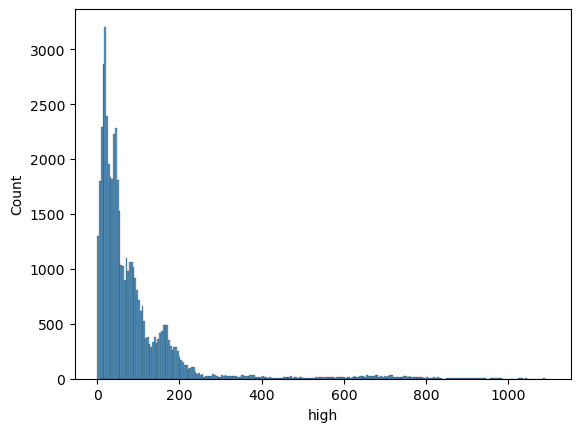

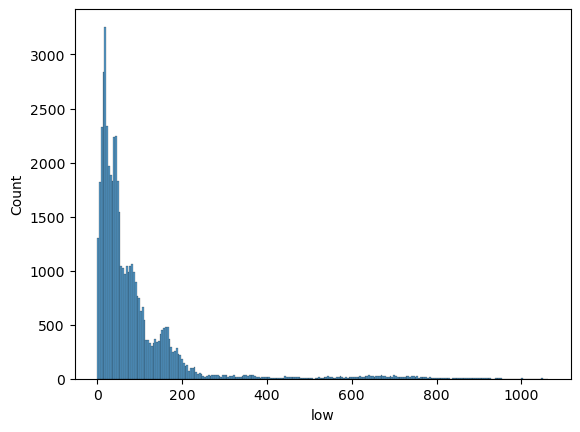

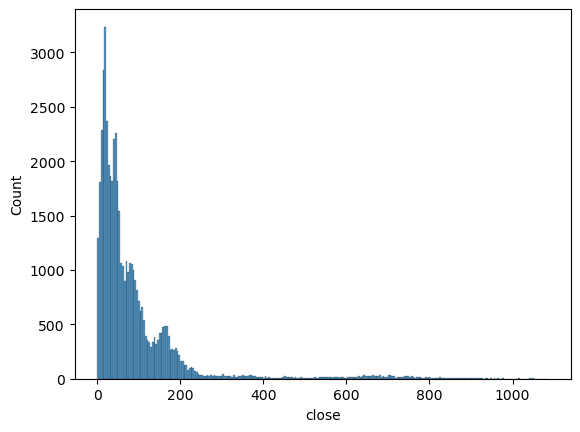

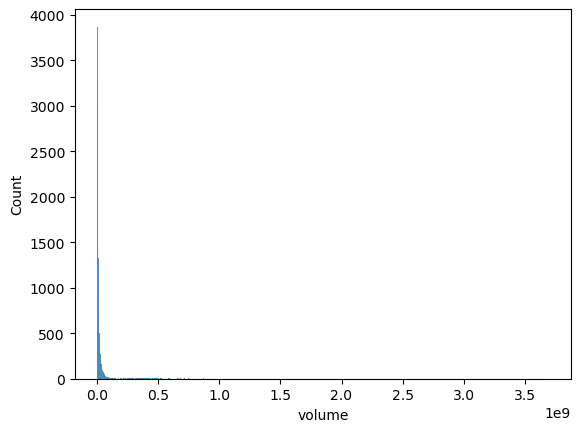

In [34]:
#Distribution Histogram
for i in df.select_dtypes (include="number").columns:
 sns.histplot(data=df,x=i)
 plt.show()

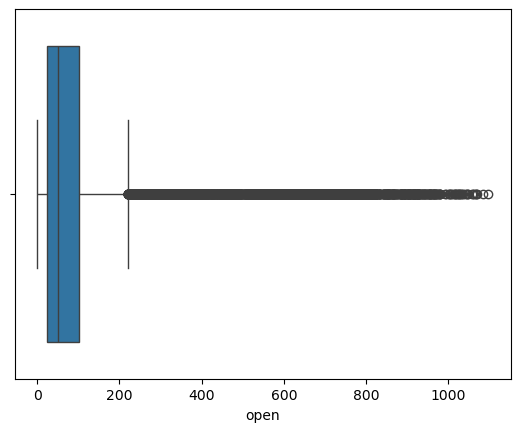

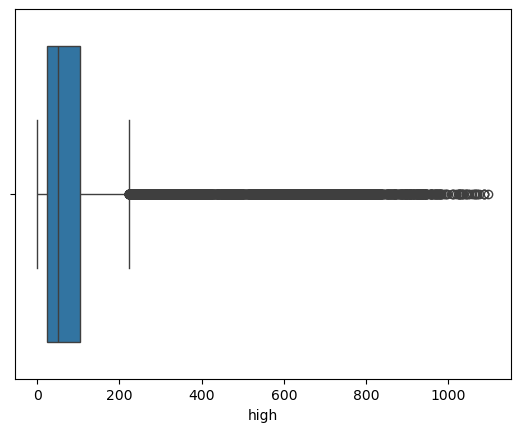

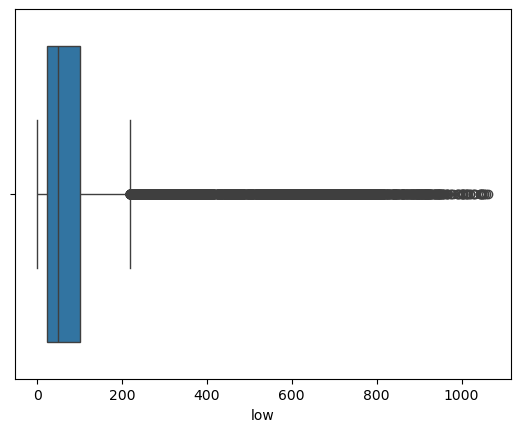

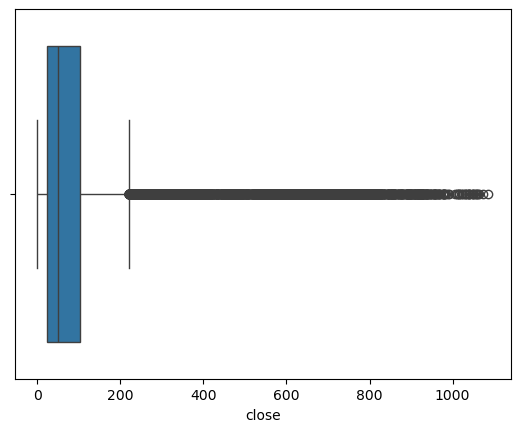

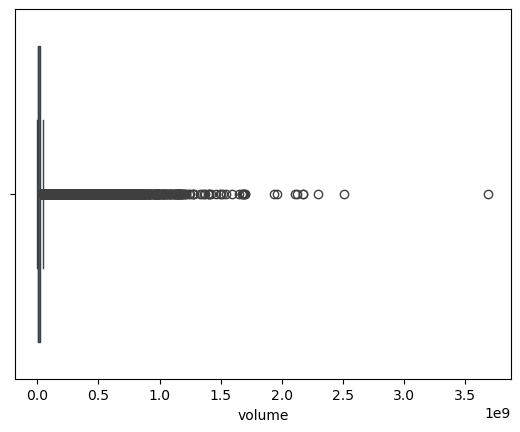

In [35]:
#Identifying outliers using boxplot
for i in df.select_dtypes (include="number").columns:
 sns.boxplot(data=df,x=i)
 plt.show()

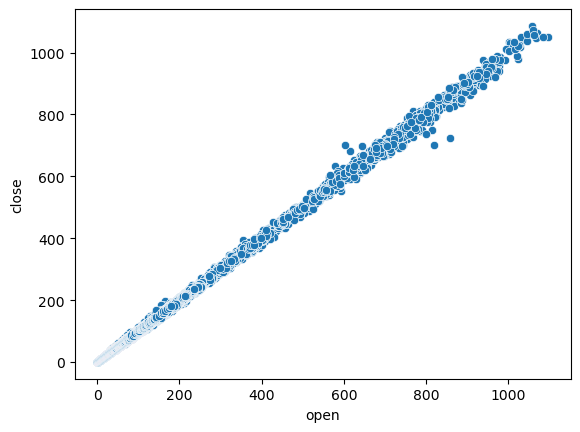

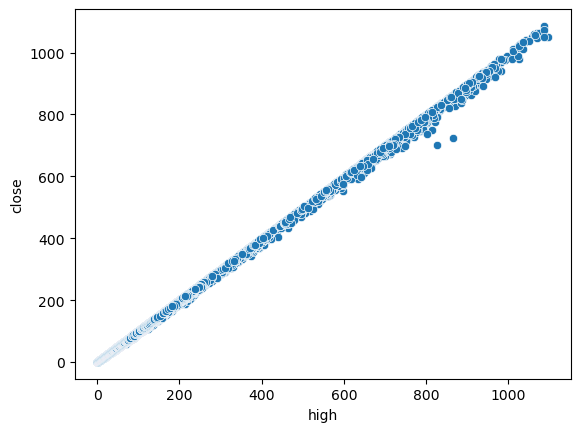

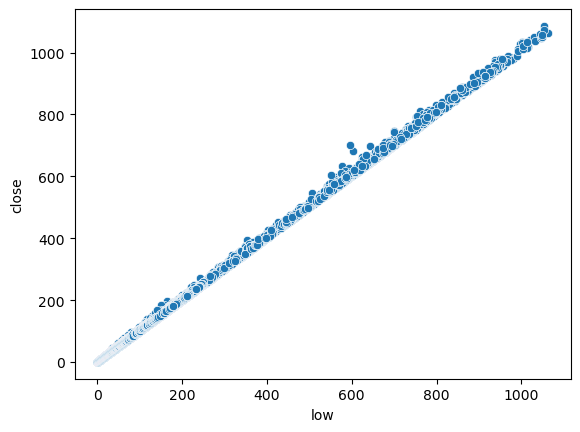

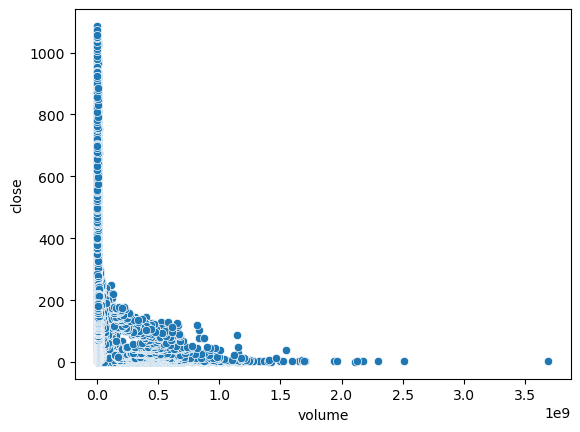

In [36]:
#Relationship of close value with others (Scatter Plot)
for i in ['open', 'high', 'low', 'volume']:
    sns.scatterplot(data=df, x=i, y='close')
    plt.show()

In [37]:
#Correlation
df.select_dtypes(include="number").corr()

,open,high,low,close,volume
open,1.000000,0.999885,0.999857,0.999715,-0.137878
high,0.999885,1.000000,0.999830,0.999861,-0.137521
low,0.999857,0.999830,1.000000,0.999889,-0.138345
close,0.999715,0.999861,0.999889,1.000000,-0.137915
volume,-0.137878,-0.137521,-0.138345,-0.137915,1.000000


<Axes: >

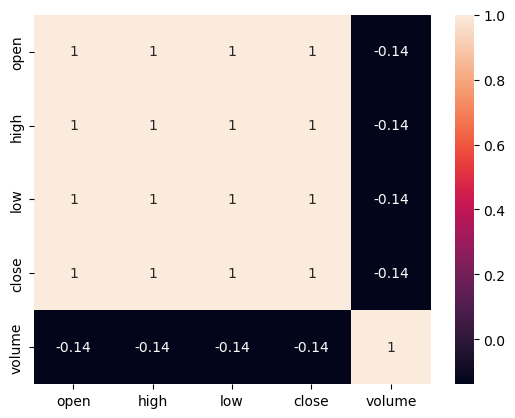

In [38]:
#Correlation Heatmap
storedata=df.select_dtypes (include="number").corr()
sns.heatmap(storedata, annot=True)

In [39]:
#Missing Value Treatment
#Check for missing values
df.isnull().sum()

company_name    0
stock_name      0
date            0
open            0
high            0
low             0
close           0
volume          0
dtype: int64

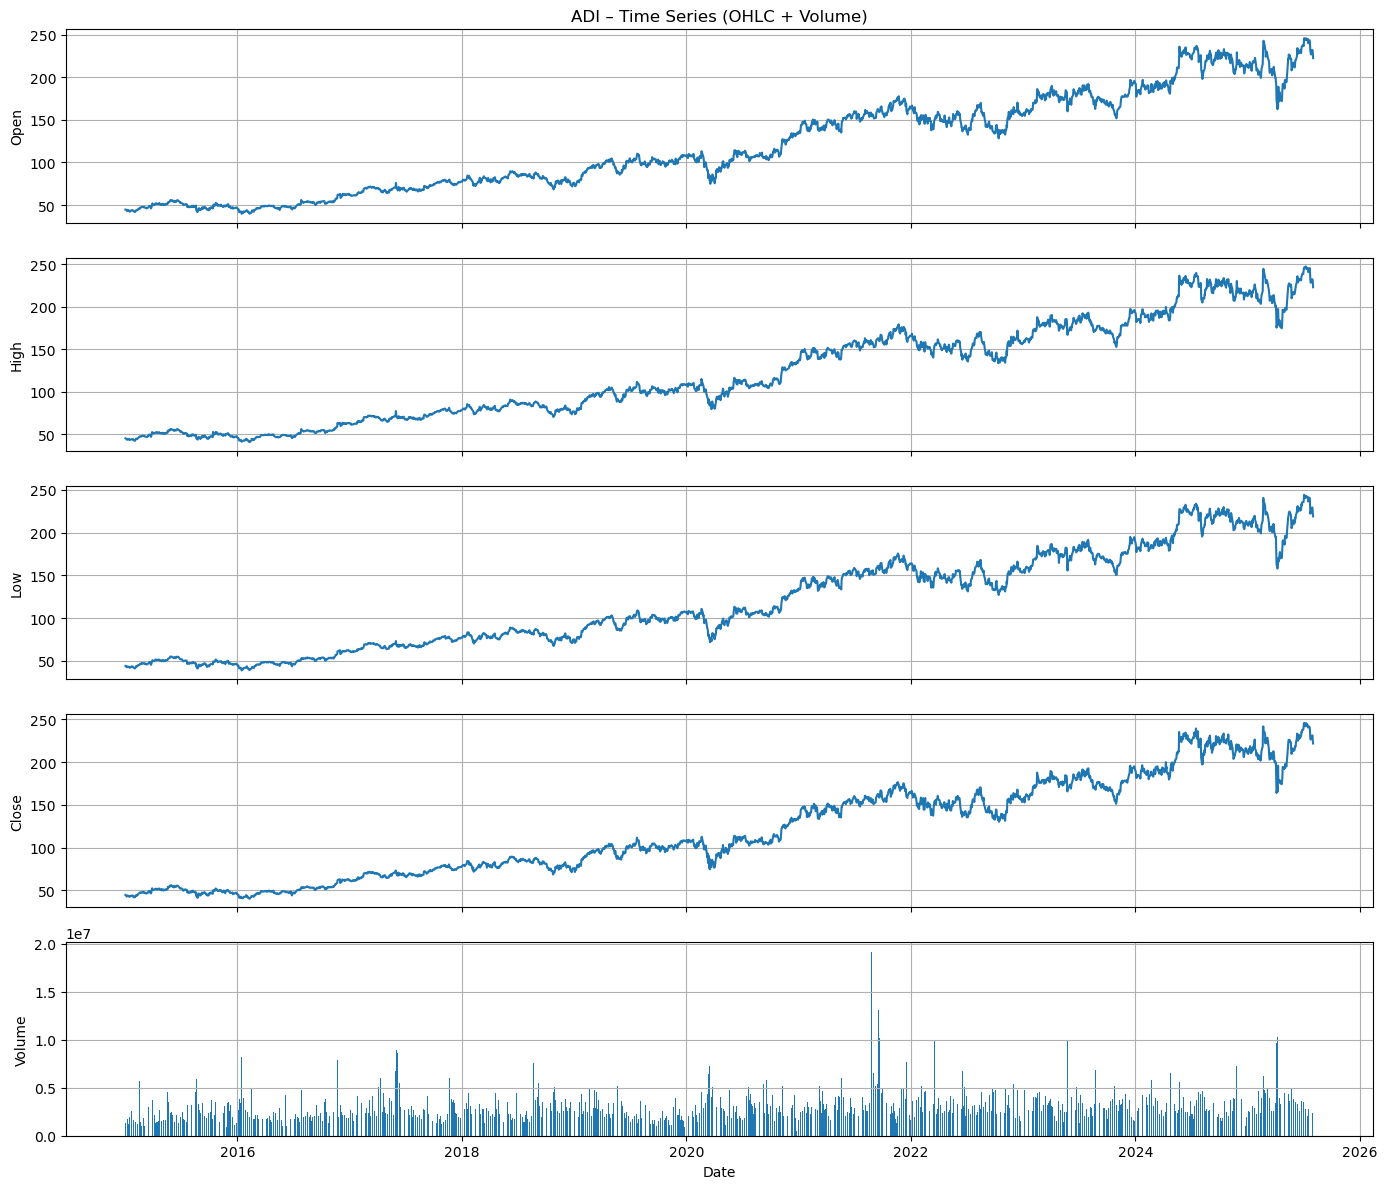

In [40]:
# -------------------------------
# 2. Parse date
# -------------------------------
df["date"] = pd.to_datetime(df["date"])

# -------------------------------
# 3. Filter one stock
# -------------------------------
stock_df = (
    df[df["stock_name"] == "ADI"]
    .sort_values("date")
    .reset_index(drop=True)
)

# -------------------------------
# 4. Create 5 subplots
# -------------------------------
fig, axes = plt.subplots(
    5, 1,
    figsize=(14, 12),
    sharex=True
)

# ---- Open
axes[0].plot(stock_df["date"], stock_df["open"])
axes[0].set_ylabel("Open")
axes[0].set_title("ADI – Time Series (OHLC + Volume)")
axes[0].grid(True)

# ---- High
axes[1].plot(stock_df["date"], stock_df["high"])
axes[1].set_ylabel("High")
axes[1].grid(True)

# ---- Low
axes[2].plot(stock_df["date"], stock_df["low"])
axes[2].set_ylabel("Low")
axes[2].grid(True)

# ---- Close
axes[3].plot(stock_df["date"], stock_df["close"])
axes[3].set_ylabel("Close")
axes[3].grid(True)

# ---- Volume
axes[4].bar(stock_df["date"], stock_df["volume"])
axes[4].set_ylabel("Volume")
axes[4].set_xlabel("Date")
axes[4].grid(True)

plt.tight_layout()
plt.show()


Time-Series Visualization

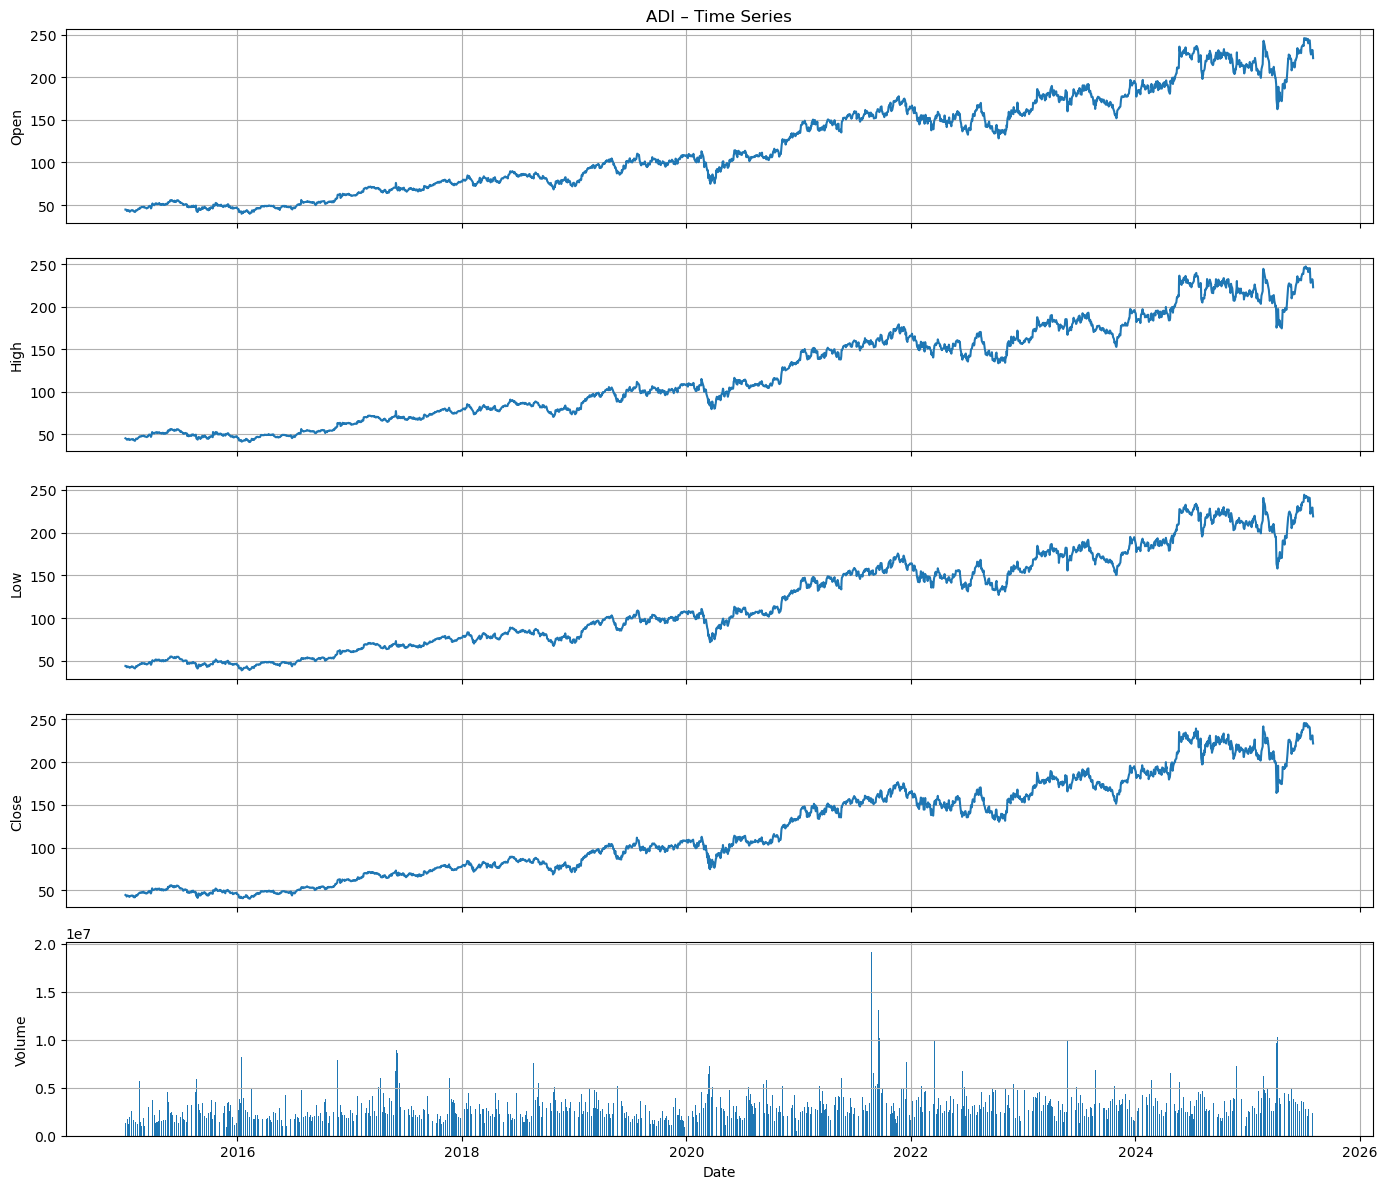

In [41]:
df["date"] = pd.to_datetime(df["date"])

# Filter ADI stock data
stock_df = (
    df[df["stock_name"] == "ADI"]
    .sort_values("date")
    .reset_index(drop=True)
)


# Subplots

fig, axes = plt.subplots(
    5, 1,
    figsize=(14, 12),
    sharex=True
)

# Open
axes[0].plot(stock_df["date"], stock_df["open"])
axes[0].set_ylabel("Open")
axes[0].set_title("ADI – Time Series")
axes[0].grid(True)

# High
axes[1].plot(stock_df["date"], stock_df["high"])
axes[1].set_ylabel("High")
axes[1].grid(True)

# Low
axes[2].plot(stock_df["date"], stock_df["low"])
axes[2].set_ylabel("Low")
axes[2].grid(True)

# Close
axes[3].plot(stock_df["date"], stock_df["close"])
axes[3].set_ylabel("Close")
axes[3].grid(True)

# Volume
axes[4].bar(stock_df["date"], stock_df["volume"])
axes[4].set_ylabel("Volume")
axes[4].set_xlabel("Date")
axes[4].grid(True)

plt.tight_layout()
plt.show()


Distribution Analysis

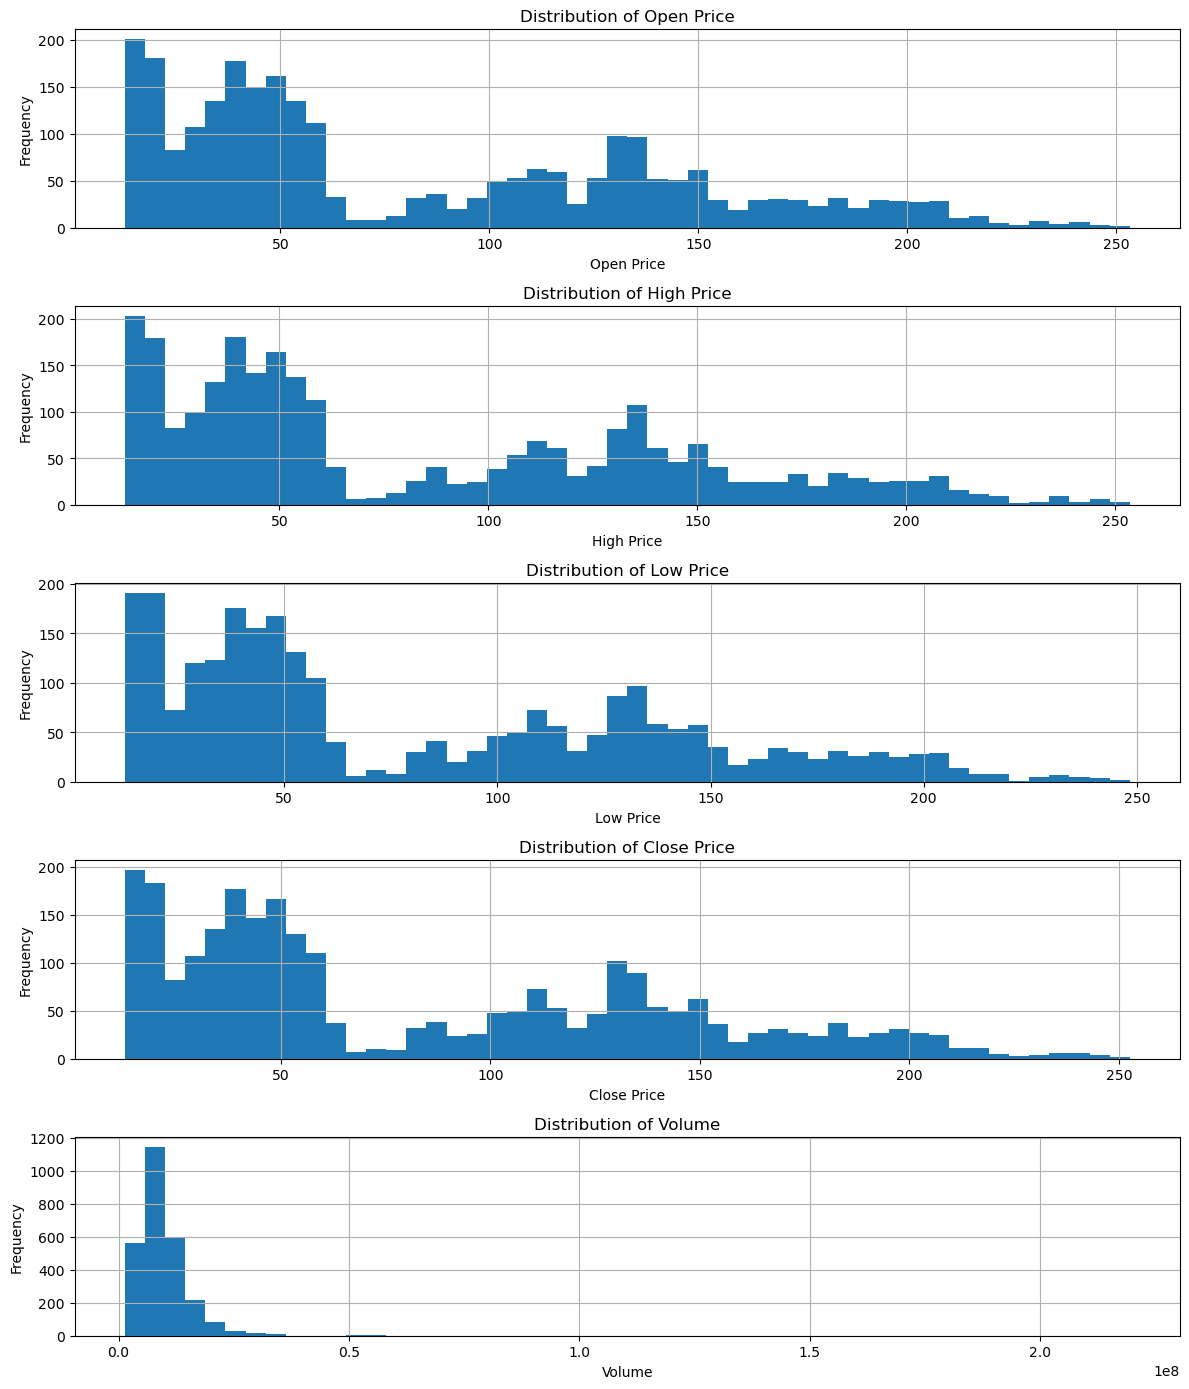

In [42]:
#Filter AMAT stock data
stock_df = df[df["stock_name"] == "AMAT"]


# Distribution plots

fig, axes = plt.subplots(
    5, 1,
    figsize=(12, 14)
)

# Open
axes[0].hist(stock_df["open"], bins=50)
axes[0].set_title("Distribution of Open Price")
axes[0].set_xlabel("Open Price")
axes[0].set_ylabel("Frequency")
axes[0].grid(True)

# High
axes[1].hist(stock_df["high"], bins=50)
axes[1].set_title("Distribution of High Price")
axes[1].set_xlabel("High Price")
axes[1].set_ylabel("Frequency")
axes[1].grid(True)

# Low
axes[2].hist(stock_df["low"], bins=50)
axes[2].set_title("Distribution of Low Price")
axes[2].set_xlabel("Low Price")
axes[2].set_ylabel("Frequency")
axes[2].grid(True)

# Close
axes[3].hist(stock_df["close"], bins=50)
axes[3].set_title("Distribution of Close Price")
axes[3].set_xlabel("Close Price")
axes[3].set_ylabel("Frequency")
axes[3].grid(True)

# Volume
axes[4].hist(stock_df["volume"], bins=50)
axes[4].set_title("Distribution of Volume")
axes[4].set_xlabel("Volume")
axes[4].set_ylabel("Frequency")
axes[4].grid(True)

plt.tight_layout()
plt.show()

Rolling Statistics

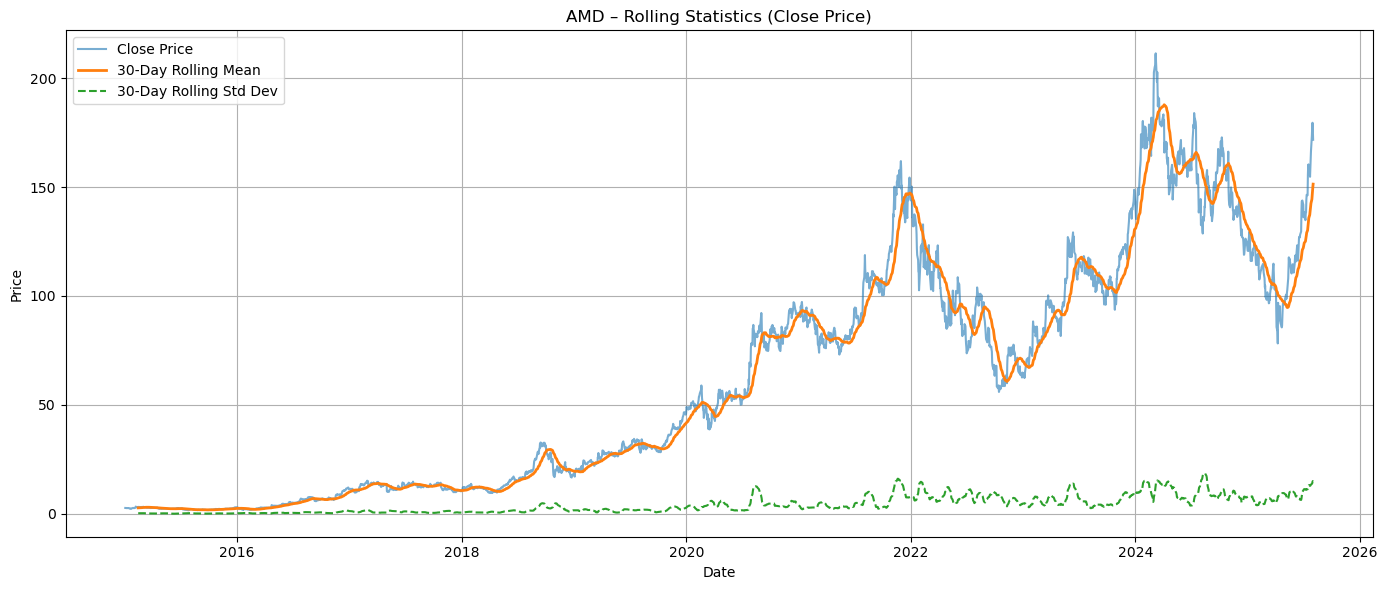

In [43]:
df["date"] = pd.to_datetime(df["date"])


# Filter AMD stock data

stock_df = (
    df[df["stock_name"] == "AMD"]
    .sort_values("date")
    .reset_index(drop=True)
)


# Rolling statistics

window_size = 30  # 30-day rolling window

stock_df["rolling_mean"] = stock_df["close"].rolling(window=window_size).mean()
stock_df["rolling_std"] = stock_df["close"].rolling(window=window_size).std()


# Plot rolling statistics

plt.figure(figsize=(14, 6))

plt.plot(stock_df["date"], stock_df["close"], label="Close Price", alpha=0.6)
plt.plot(stock_df["date"], stock_df["rolling_mean"], label="30-Day Rolling Mean", linewidth=2)
plt.plot(stock_df["date"], stock_df["rolling_std"], label="30-Day Rolling Std Dev", linestyle="--")

plt.title("AMD – Rolling Statistics (Close Price)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Correlation Analysis (Pearson and Spearman)


Pearson Correlation Matrix 
            open      high       low     close    volume
open    1.000000  0.999825  0.999749  0.999512  0.198381
high    0.999825  1.000000  0.999732  0.999761  0.201574
low     0.999749  0.999732  1.000000  0.999826  0.191219
close   0.999512  0.999761  0.999826  1.000000  0.195019
volume  0.198381  0.201574  0.191219  0.195019  1.000000

Spearman Correlation Matrix 
            open      high       low     close    volume
open    1.000000  0.999787  0.999726  0.999457  0.250041
high    0.999787  1.000000  0.999699  0.999740  0.253571
low     0.999726  0.999699  1.000000  0.999788  0.244096
close   0.999457  0.999740  0.999788  1.000000  0.248145
volume  0.250041  0.253571  0.244096  0.248145  1.000000


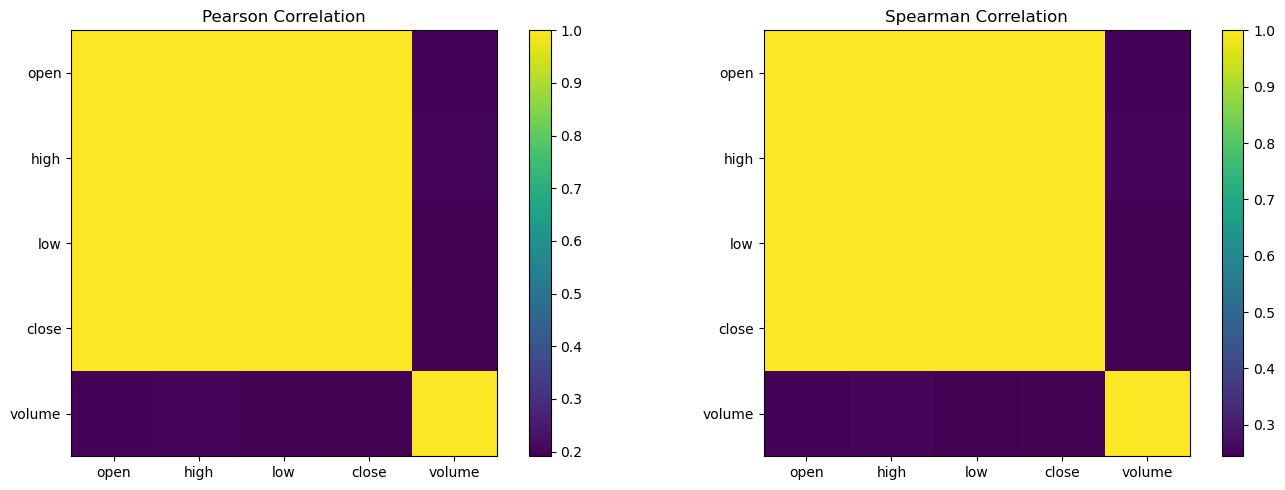


 Correlation: Returns vs Volume  
         returns   volume
returns  1.00000 -0.07283
volume  -0.07283  1.00000


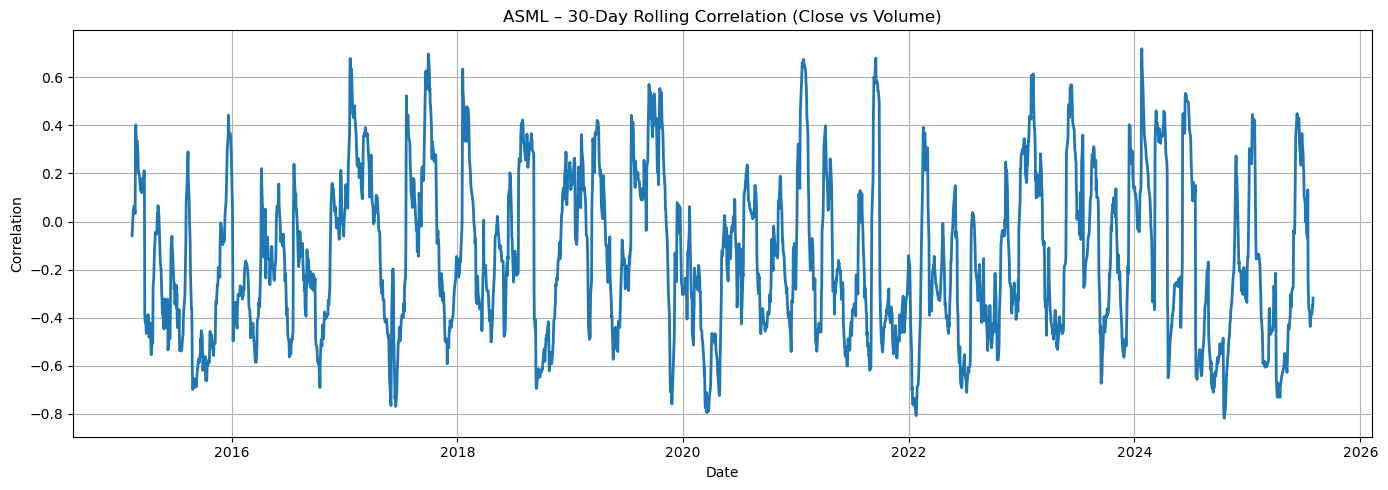

In [44]:
df["date"] = pd.to_datetime(df["date"])


# Filter ASML stock data

stock_df = (
    df[df["stock_name"] == "ASML"]
    .sort_values("date")
    .reset_index(drop=True)
)


# Select numerical features

features = ["open", "high", "low", "close", "volume"]
data = stock_df[features]


# Pearson correlation

pearson_corr = data.corr(method="pearson")
print("\nPearson Correlation Matrix ")
print(pearson_corr)


# Spearman correlation

spearman_corr = data.corr(method="spearman")
print("\nSpearman Correlation Matrix ")
print(spearman_corr)


# Visualize correlation matrices

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im1 = axes[0].imshow(pearson_corr)
axes[0].set_title("Pearson Correlation")
axes[0].set_xticks(range(len(features)))
axes[0].set_yticks(range(len(features)))
axes[0].set_xticklabels(features)
axes[0].set_yticklabels(features)
plt.colorbar(im1, ax=axes[0], fraction=0.046)

im2 = axes[1].imshow(spearman_corr)
axes[1].set_title("Spearman Correlation")
axes[1].set_xticks(range(len(features)))
axes[1].set_yticks(range(len(features)))
axes[1].set_xticklabels(features)
axes[1].set_yticklabels(features)
plt.colorbar(im2, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.show()


# RETURNS vs VOLUME CORRELATION

# Calculate daily returns
stock_df["returns"] = stock_df["close"].pct_change()

returns_corr = stock_df[["returns", "volume"]].corr()
print("\n Correlation: Returns vs Volume  ")
print(returns_corr)


# ROLLING CORRELATION (Advanced)


window_size = 30  # 30-day rolling window
stock_df["rolling_corr_close_volume"] = (
    stock_df["close"]
    .rolling(window_size)
    .corr(stock_df["volume"])
)

# Plot rolling correlation
plt.figure(figsize=(14, 5))

plt.plot(
    stock_df["date"],
    stock_df["rolling_corr_close_volume"],
    linewidth=2
)

plt.title("ASML – 30-Day Rolling Correlation (Close vs Volume)")
plt.xlabel("Date")
plt.ylabel("Correlation")
plt.grid(True)

plt.tight_layout()
plt.show()